In [1]:
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import Dataset,DataLoader
from sklearn.model_selection import train_test_split


# data_preproseccing

In [2]:
torch.manual_seed(42)#Random ness fix kore protek bar same result pawar jnne

In [3]:
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [4]:
df=pd.read_csv('/content/fashion-mnist_test.csv')
df

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,9,8,...,103,87,56,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,34,0,0,0,0,0,0,0,0,0
2,2,0,0,0,0,0,0,14,53,99,...,0,0,0,0,63,53,31,0,0,0
3,2,0,0,0,0,0,0,0,0,0,...,137,126,140,0,133,224,222,56,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,0,0,0,0,0,0,0,0,0,0,...,32,23,14,20,0,0,1,0,0,0
9996,6,0,0,0,0,0,0,0,0,0,...,0,0,0,2,52,23,28,0,0,0
9997,8,0,0,0,0,0,0,0,0,0,...,175,172,172,182,199,222,42,0,1,0
9998,8,0,1,3,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Columns: 785 entries, label to pixel784
dtypes: int64(785)
memory usage: 59.9 MB


In [6]:
df.isna().sum()

,0
label,0
pixel1,0
pixel2,0
pixel3,0
pixel4,0
...,...
pixel780,0
pixel781,0
pixel782,0
pixel783,0


In [7]:
#train_test_split
X=df.iloc[:,1:].values
y=df.iloc[:,0].values

In [8]:
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,
    random_state=42
)


In [9]:
X_train = X_train / 255.0
X_test = X_test / 255.0

# Basic graph

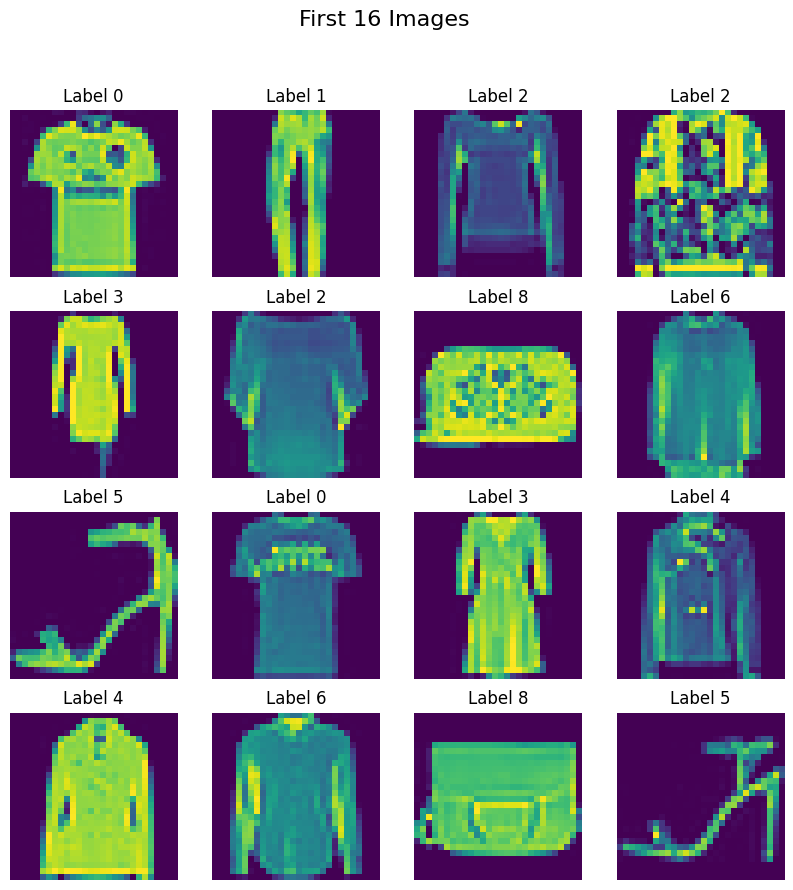

In [10]:
fig , axes = plt.subplots(4,4,figsize=(10,10))
fig.suptitle("First 16 Images",fontsize=16)

for i ,ax in enumerate(axes.flat):
  img = df.iloc[i,1:].values.reshape(28,28)
  ax.imshow(img)
  ax.axis('off')

  ax.set_title(f"Label {df.iloc[i,0]}")

In [11]:
len(df.columns)

785

In [12]:
len(df['label'].unique())

10

In [13]:
len(df.iloc[:,1:])

10000

# Custom_Dataset

Dataset

In [14]:
class CustomDataset(Dataset):
  def __init__(self, features, labels):
    self.features = torch.tensor(features, dtype=torch.float32)
    self.labels = torch.tensor(labels, dtype=torch.long)

  def __len__(self):
    return len(self.features)
  def __getitem__(self,index):
    return self.features[index], self.labels[index]

In [15]:
train_dataset =CustomDataset(X_train,y_train)
test_dataset =CustomDataset(X_test,y_test)

In [16]:
len(train_dataset)

8000

In [17]:
len(test_dataset)

2000

In [18]:
train_dataset[1]


(tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0588, 0.2039, 0.0000,
         0.0235, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0078, 0.0118, 0.0078,
         0.0118, 0.0118, 0.0275, 0.0078, 0.0078, 0.0000, 0.0000, 0.7765, 0.8392,
         0.0000, 0.0000, 0.0078, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0078, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.7843, 1.0000,
         0.8941, 0.1451, 0.0

In [19]:
train_loader= DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    pin_memory=True
)
test_loader= DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=False,
    pin_memory=True
)

# Define NN class

In [20]:
class MyNN(nn.Module):
  def __init__(self,num_features):
    super().__init__()

    self.model = nn.Sequential(
        nn.Linear(num_features,128),
        nn.ReLU(),
        nn.Linear(128,64),
        nn.ReLU(),
        nn.Linear(64,10)
    )

  def forward(self, X):
    return self.model(X)



# Instantiate Model

In [21]:
epochs =20
learning_rate = 0.1

In [22]:
model = MyNN(X_train.shape[1])
model=model.to(device)
# loss function-->BCE/CrossEntropy
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(),lr=learning_rate)

In [23]:
model.parameters()

<generator object Module.parameters at 0x7ec80e8e03c0>

In [24]:
len(train_loader)

250

# training loop

In [25]:
for epoch in range(epochs):
  total_epoch_loss =0

  for batch_features, batch_labels in train_loader:
    #move cpu to gpu
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
    #forward
    output = model(batch_features)
    #calculate loss
    loss = criterion(output, batch_labels)
    #back pass
    optimizer.zero_grad()
    loss.backward()
    #update
    optimizer.step()
    total_epoch_loss = total_epoch_loss + loss.item()
avg_loss = total_epoch_loss / len(train_loader)
print(avg_loss)

0.25191450752317907


In [26]:
model.eval()

total = 0
correct = 0


with torch.no_grad():
  for batch_features,batch_labels in test_loader:
    #move cpu to gpu
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
    outputs = model(batch_features)
    # print(f" outputs {outputs}")
    _,predicted = torch.max(outputs,1)
    # print(f"predicted {predicted}")

    #total
    total = total + batch_labels.shape[0]

    correct = correct + (predicted==batch_labels).sum().item()


print(correct/total)
# print(f"total number {total}")
# print(f"correct {correct}")

0.9155
